In [9]:
import pandas as pd

path = r"C:\Users\lamar\OneDrive\Desktop\Data\Mental health data\mental_health_evaluation_data.csv"
df = pd.read_csv(path)
print(df.head())

   Anxiety Level  Depression Level  Stress Level  Sleep Quality  \
0              3                 1             7           8.77   
1              9                10             0           9.94   
2              3                 6             0           5.16   
3              3                 0             6           8.33   
4              6                10             7           3.02   

   Academic Performance  Social Interaction Frequency  Self-esteem  \
0                  8.68                           NaN         4.00   
1                  8.11                           NaN         6.60   
2                  1.23                           NaN         6.20   
3                  6.37                           NaN         2.54   
4                  2.90                           NaN         8.78   

   Physical Activity Level Nutrition Quality Substance Use  ... Peer Pressure  \
0                     0.92              Good            No  ...            No   
1             

In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100
Number of columns: 26


In [11]:
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. Anxiety Level
2. Depression Level
3. Stress Level
4. Sleep Quality
5. Academic Performance
6. Social Interaction Frequency
7. Self-esteem
8. Physical Activity Level
9. Nutrition Quality
10. Substance Use
11. Family Support
12. Peer Support
13. Time Spent on Social Media
14. Academic Stress
15. Sleep Pattern Consistency
16. Emotional Stability
17. Peer Pressure
18. Eating Habits
19. Work-Life Balance
20. Motivation Level
21. Academic Engagement
22. Loneliness
23. Social Media Addiction
24. Mood Fluctuations
25. Academic Pressure from Parents
26. Relationship with Teachers


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Anxiety Level                   100 non-null    int64  
 1   Depression Level                100 non-null    int64  
 2   Stress Level                    100 non-null    int64  
 3   Sleep Quality                   100 non-null    float64
 4   Academic Performance            100 non-null    float64
 5   Social Interaction Frequency    0 non-null      float64
 6   Self-esteem                     100 non-null    float64
 7   Physical Activity Level         100 non-null    float64
 8   Nutrition Quality               100 non-null    str    
 9   Substance Use                   100 non-null    str    
 10  Family Support                  100 non-null    str    
 11  Peer Support                    100 non-null    str    
 12  Time Spent on Social Media      100 non-null    

In [13]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Anxiety Level                       0
Depression Level                    0
Stress Level                        0
Sleep Quality                       0
Academic Performance                0
Social Interaction Frequency      100
Self-esteem                         0
Physical Activity Level             0
Nutrition Quality                   0
Substance Use                       0
Family Support                      0
Peer Support                        0
Time Spent on Social Media          0
Academic Stress                     0
Sleep Pattern Consistency           0
Emotional Stability                 0
Peer Pressure                       0
Eating Habits                       0
Work-Life Balance                   0
Motivation Level                    0
Academic Engagement                 0
Loneliness                          0
Social Media Addiction              0
Mood Fluctuations                   0
Academic Pressure from Parents      0
Relationship with Teach

In [14]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [15]:
categorical_cols = [
    "Nutrition Quality",
    "Substance Use",
    "Family Support",
    "Peer Support",
    "Sleep Pattern Consistency",
    "Peer Pressure",
    "Eating Habits",
    "Social Media Addiction",
    "Relationship with Teachers"
]

for col in categorical_cols:
    print(f"\n📌 {col}:")
    print(df[col].value_counts())


📌 Nutrition Quality:
Nutrition Quality
Good        38
Poor        34
Moderate    28
Name: count, dtype: int64

📌 Substance Use:
Substance Use
No     51
Yes    49
Name: count, dtype: int64

📌 Family Support:
Family Support
Low       36
Medium    34
High      30
Name: count, dtype: int64

📌 Peer Support:
Peer Support
High      35
Medium    35
Low       30
Name: count, dtype: int64

📌 Sleep Pattern Consistency:
Sleep Pattern Consistency
Irregular    58
Regular      42
Name: count, dtype: int64

📌 Peer Pressure:
Peer Pressure
No     50
Yes    50
Name: count, dtype: int64

📌 Eating Habits:
Eating Habits
Unhealthy    41
Moderate     32
Healthy      27
Name: count, dtype: int64

📌 Social Media Addiction:
Social Media Addiction
Yes    51
No     49
Name: count, dtype: int64

📌 Relationship with Teachers:
Relationship with Teachers
Neutral     39
Negative    34
Positive    27
Name: count, dtype: int64


In [16]:
df_clean = df.copy()
print("Copied successfully. Shape:", df_clean.shape)

Copied successfully. Shape: (100, 26)


In [17]:
df_clean = df_clean.drop(columns=["Social Interaction Frequency"])
print("New shape after dropping empty column:", df_clean.shape)

New shape after dropping empty column: (100, 25)


In [18]:
# Mapping dictionaries: text → number
mappings = {
    "Nutrition Quality": {"Poor": 0, "Moderate": 1, "Good": 2},
    "Substance Use": {"No": 0, "Yes": 1},
    "Family Support": {"Low": 0, "Medium": 1, "High": 2},
    "Peer Support": {"Low": 0, "Medium": 1, "High": 2},
    "Sleep Pattern Consistency": {"Irregular": 0, "Regular": 1},
    "Peer Pressure": {"No": 0, "Yes": 1},
    "Eating Habits": {"Unhealthy": 0, "Moderate": 1, "Healthy": 2},
    "Social Media Addiction": {"No": 0, "Yes": 1},
    "Relationship with Teachers": {"Negative": 0, "Neutral": 1, "Positive": 2},
}

# Apply the mapping to each column
for col, mapping in mappings.items():
    df_clean[col] = df_clean[col].map(mapping)

print("Encoding done. First 5 rows:")
print(df_clean.head())

Encoding done. First 5 rows:
   Anxiety Level  Depression Level  Stress Level  Sleep Quality  \
0              3                 1             7           8.77   
1              9                10             0           9.94   
2              3                 6             0           5.16   
3              3                 0             6           8.33   
4              6                10             7           3.02   

   Academic Performance  Self-esteem  Physical Activity Level  \
0                  8.68         4.00                     0.92   
1                  8.11         6.60                     1.34   
2                  1.23         6.20                     6.94   
3                  6.37         2.54                     4.84   
4                  2.90         8.78                     1.94   

   Nutrition Quality  Substance Use  Family Support  ...  Peer Pressure  \
0                  2              0               0  ...              0   
1                  2       

In [19]:
print("Data types after encoding:")
print(df_clean.dtypes)

Data types after encoding:
Anxiety Level                       int64
Depression Level                    int64
Stress Level                        int64
Sleep Quality                     float64
Academic Performance              float64
Self-esteem                       float64
Physical Activity Level           float64
Nutrition Quality                   int64
Substance Use                       int64
Family Support                      int64
Peer Support                        int64
Time Spent on Social Media        float64
Academic Stress                     int64
Sleep Pattern Consistency           int64
Emotional Stability                 int64
Peer Pressure                       int64
Eating Habits                       int64
Work-Life Balance                 float64
Motivation Level                  float64
Academic Engagement               float64
Loneliness                          int64
Social Media Addiction              int64
Mood Fluctuations                   int64
Academi

In [20]:
df_clean["Mental_Health_Score"] = (
    df_clean["Anxiety Level"]
    + df_clean["Depression Level"]
    + df_clean["Stress Level"]
)

print("Mental Health Score added.")
print(df_clean["Mental_Health_Score"].describe())

Mental Health Score added.
count    100.00000
mean      15.61000
std        5.04504
min        3.00000
25%       11.75000
50%       16.00000
75%       19.00000
max       27.00000
Name: Mental_Health_Score, dtype: float64


In [21]:
df_clean["Wellness_Index"] = (
    df_clean["Sleep Quality"]
    + df_clean["Self-esteem"]
    + df_clean["Emotional Stability"]
) / 3

print("Wellness Index added.")
print(df_clean["Wellness_Index"].describe())

Wellness Index added.
count    100.000000
mean       5.193333
std        1.695623
min        1.600000
25%        3.972500
50%        4.880000
75%        6.515000
max        8.686667
Name: Wellness_Index, dtype: float64


In [22]:
df_clean["Social_Support_Score"] = (
    df_clean["Family Support"]
    + df_clean["Peer Support"]
)

print("Social Support Score added.")
print(df_clean["Social_Support_Score"].value_counts().sort_index())

Social Support Score added.
Social_Support_Score
0     9
1    27
2    34
3    16
4    14
Name: count, dtype: int64


In [23]:
import pandas as pd

df_clean["Risk_Level"] = pd.cut(
    df_clean["Mental_Health_Score"],
    bins=[-1, 8, 16, 30],
    labels=["Low", "Medium", "High"]
)

print("Risk Level added.")
print(df_clean["Risk_Level"].value_counts())

Risk Level added.
Risk_Level
Medium    46
High      45
Low        9
Name: count, dtype: int64


In [24]:
print("Final shape:", df_clean.shape)
print("\nNew columns:")
print(df_clean[["Mental_Health_Score", "Wellness_Index", "Social_Support_Score", "Risk_Level"]].head(10))

Final shape: (100, 29)

New columns:
   Mental_Health_Score  Wellness_Index  Social_Support_Score Risk_Level
0                   11        5.923333                     2     Medium
1                   19        8.180000                     1       High
2                    9        4.453333                     3     Medium
3                    9        3.623333                     1     Medium
4                   23        6.933333                     2       High
5                   24        4.090000                     4       High
6                   16        5.020000                     2     Medium
7                   20        3.233333                     1       High
8                   20        3.046667                     3       High
9                   17        6.090000                     2       High


In [25]:
correlations = df_clean.corr(numeric_only=True)["Mental_Health_Score"].sort_values(ascending=False)
print("Correlation with Mental Health Score:")
print(correlations.round(3))

Correlation with Mental Health Score:
Mental_Health_Score               1.000
Depression Level                  0.560
Anxiety Level                     0.548
Stress Level                      0.487
Substance Use                     0.311
Nutrition Quality                 0.166
Social_Support_Score              0.138
Peer Support                      0.104
Peer Pressure                     0.098
Family Support                    0.095
Academic Pressure from Parents    0.082
Sleep Pattern Consistency         0.070
Academic Engagement               0.066
Emotional Stability               0.053
Loneliness                       -0.001
Academic Stress                  -0.004
Social Media Addiction           -0.004
Eating Habits                    -0.008
Physical Activity Level          -0.014
Self-esteem                      -0.019
Time Spent on Social Media       -0.070
Academic Performance             -0.071
Mood Fluctuations                -0.083
Wellness_Index                   -0.088
Wo

In [26]:
top_factors = correlations.drop("Mental_Health_Score").head(10)
print("Top 10 factors INCREASING mental health issues:")
print(top_factors.round(3))

Top 10 factors INCREASING mental health issues:
Depression Level                  0.560
Anxiety Level                     0.548
Stress Level                      0.487
Substance Use                     0.311
Nutrition Quality                 0.166
Social_Support_Score              0.138
Peer Support                      0.104
Peer Pressure                     0.098
Family Support                    0.095
Academic Pressure from Parents    0.082
Name: Mental_Health_Score, dtype: float64


In [27]:
protective_factors = correlations.drop("Mental_Health_Score").tail(10)
print("Top 10 factors DECREASING mental health issues (protective):")
print(protective_factors.round(3))

Top 10 factors DECREASING mental health issues (protective):
Physical Activity Level      -0.014
Self-esteem                  -0.019
Time Spent on Social Media   -0.070
Academic Performance         -0.071
Mood Fluctuations            -0.083
Wellness_Index               -0.088
Work-Life Balance            -0.150
Sleep Quality                -0.187
Relationship with Teachers   -0.214
Motivation Level             -0.268
Name: Mental_Health_Score, dtype: float64


In [28]:
group_analysis = df_clean.groupby("Risk_Level", observed=True)[[
    "Sleep Quality",
    "Academic Performance",
    "Motivation Level",
    "Substance Use",
    "Relationship with Teachers",
    "Wellness_Index"
]].mean().round(2)

print("Comparison by Risk Level:")
print(group_analysis)

Comparison by Risk Level:
            Sleep Quality  Academic Performance  Motivation Level  \
Risk_Level                                                          
Low                  5.14                  6.58              6.04   
Medium               6.31                  5.08              5.10   
High                 4.70                  5.10              4.20   

            Substance Use  Relationship with Teachers  Wellness_Index  
Risk_Level                                                             
Low                  0.11                        1.56            4.94  
Medium               0.41                        0.91            5.61  
High                 0.64                        0.82            4.82  


In [29]:
social_media_analysis = df_clean.groupby("Social Media Addiction", observed=True)[[
    "Mental_Health_Score",
    "Loneliness",
    "Sleep Quality",
    "Academic Performance",
    "Mood Fluctuations"
]].mean().round(2)

print("Impact of Social Media Addiction (0=No, 1=Yes):")
print(social_media_analysis)

Impact of Social Media Addiction (0=No, 1=Yes):
                        Mental_Health_Score  Loneliness  Sleep Quality  \
Social Media Addiction                                                   
0                                     15.63        5.84           5.06   
1                                     15.59        4.94           5.89   

                        Academic Performance  Mood Fluctuations  
Social Media Addiction                                           
0                                       4.89               5.88  
1                                       5.54               4.65  


In [31]:
teacher_analysis = df_clean.groupby("Relationship with Teachers", observed=True)[[
    "Mental_Health_Score",
    "Motivation Level",
    "Academic Performance"
]].mean().round(2)

print("Impact of Teacher Relationship (0=Negative, 1=Neutral, 2=Positive):")
print(teacher_analysis)

Impact of Teacher Relationship (0=Negative, 1=Neutral, 2=Positive):
                            Mental_Health_Score  Motivation Level  \
Relationship with Teachers                                          
0                                         17.06              4.61   
1                                         15.23              4.69   
2                                         14.33              5.11   

                            Academic Performance  
Relationship with Teachers                        
0                                           5.15  
1                                           4.89  
2                                           5.79  


In [32]:
risk_distribution = pd.crosstab(
    df_clean["Relationship with Teachers"],
    df_clean["Risk_Level"]
)

print("Risk Level distribution by Teacher Relationship:")
print(risk_distribution)

Risk Level distribution by Teacher Relationship:
Risk_Level                  Low  Medium  High
Relationship with Teachers                   
0                             1      15    18
1                             2      20    17
2                             6      11    10


In [33]:
risk_pct = pd.crosstab(
    df_clean["Relationship with Teachers"],
    df_clean["Risk_Level"],
    normalize="index"
).round(2) * 100

print("Risk Level (%) by Teacher Relationship:")
print(risk_pct)

Risk Level (%) by Teacher Relationship:
Risk_Level                   Low  Medium  High
Relationship with Teachers                    
0                            3.0    44.0  53.0
1                            5.0    51.0  44.0
2                           22.0    41.0  37.0


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# === PROFESSIONAL THEME ===
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#CCCCCC",
    "axes.labelcolor": "#2C3E50",
    "axes.titlecolor": "#2C3E50",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.color": "#E8E8E8",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.7,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "#FAFAFA",
})

# === PROFESSIONAL COLOR PALETTE ===
COLORS = {
    "primary": "#2C3E50",
    "accent":  "#E74C3C",
    "success": "#27AE60",
    "warning": "#F39C12",
    "info":    "#3498DB",
    "purple":  "#9B59B6",
    "teal":    "#1ABC9C",
    "gray":    "#95A5A6",
}

RISK_COLORS = {
    "Low":    "#27AE60",
    "Medium": "#F39C12",
    "High":   "#E74C3C",
}

print("✅ Professional theme applied!")

✅ Professional theme applied!


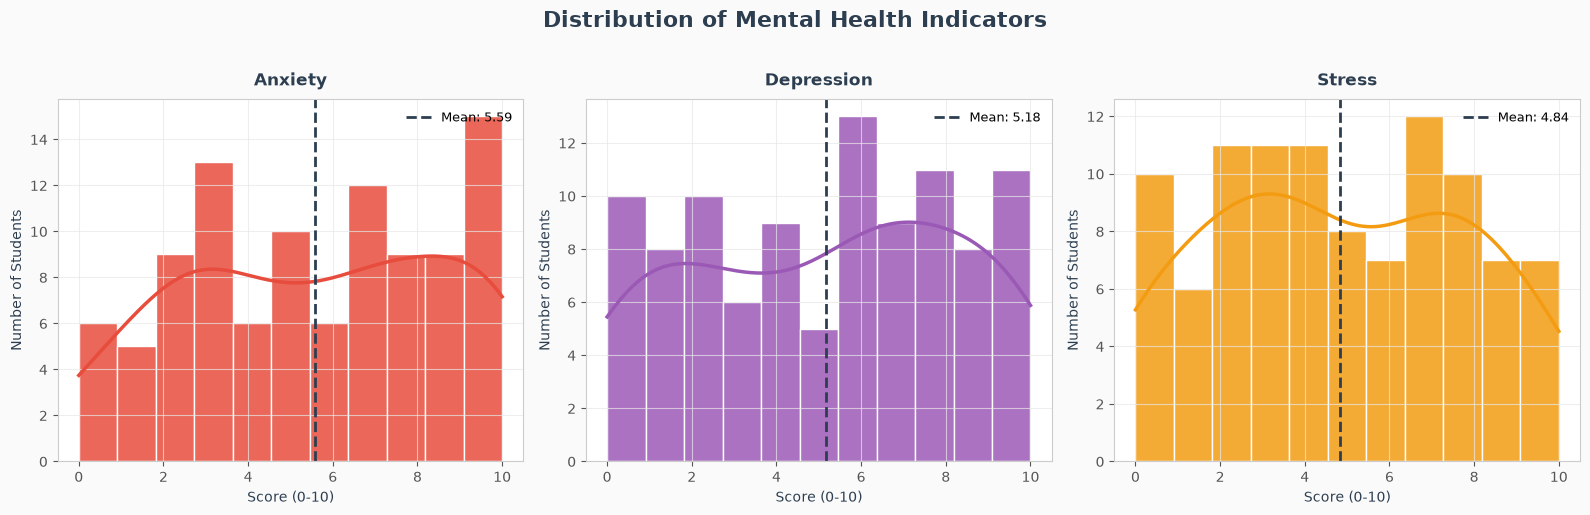

✅ Chart 1 saved: chart1_distributions.png


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution of Mental Health Indicators",
             fontsize=16, fontweight="bold", color="#2C3E50", y=1.02)

indicators = [
    ("Anxiety Level",    COLORS["accent"],  "Anxiety"),
    ("Depression Level", COLORS["purple"],  "Depression"),
    ("Stress Level",     COLORS["warning"], "Stress"),
]

for ax, (col, color, label) in zip(axes, indicators):
    # Histogram with KDE curve
    sns.histplot(
        df_clean[col], bins=11, kde=True, ax=ax,
        color=color, edgecolor="white",
        alpha=0.85,
        line_kws={"linewidth": 2.5}
    )

    # Mean line
    mean_val = df_clean[col].mean()
    ax.axvline(mean_val, color=COLORS["primary"], linestyle="--",
               linewidth=2, label=f"Mean: {mean_val:.2f}")

    # Labels
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_xlabel("Score (0-10)", fontsize=10)
    ax.set_ylabel("Number of Students", fontsize=10)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim(-0.5, 10.5)

plt.tight_layout()
plt.savefig("chart1_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Chart 1 saved: chart1_distributions.png")

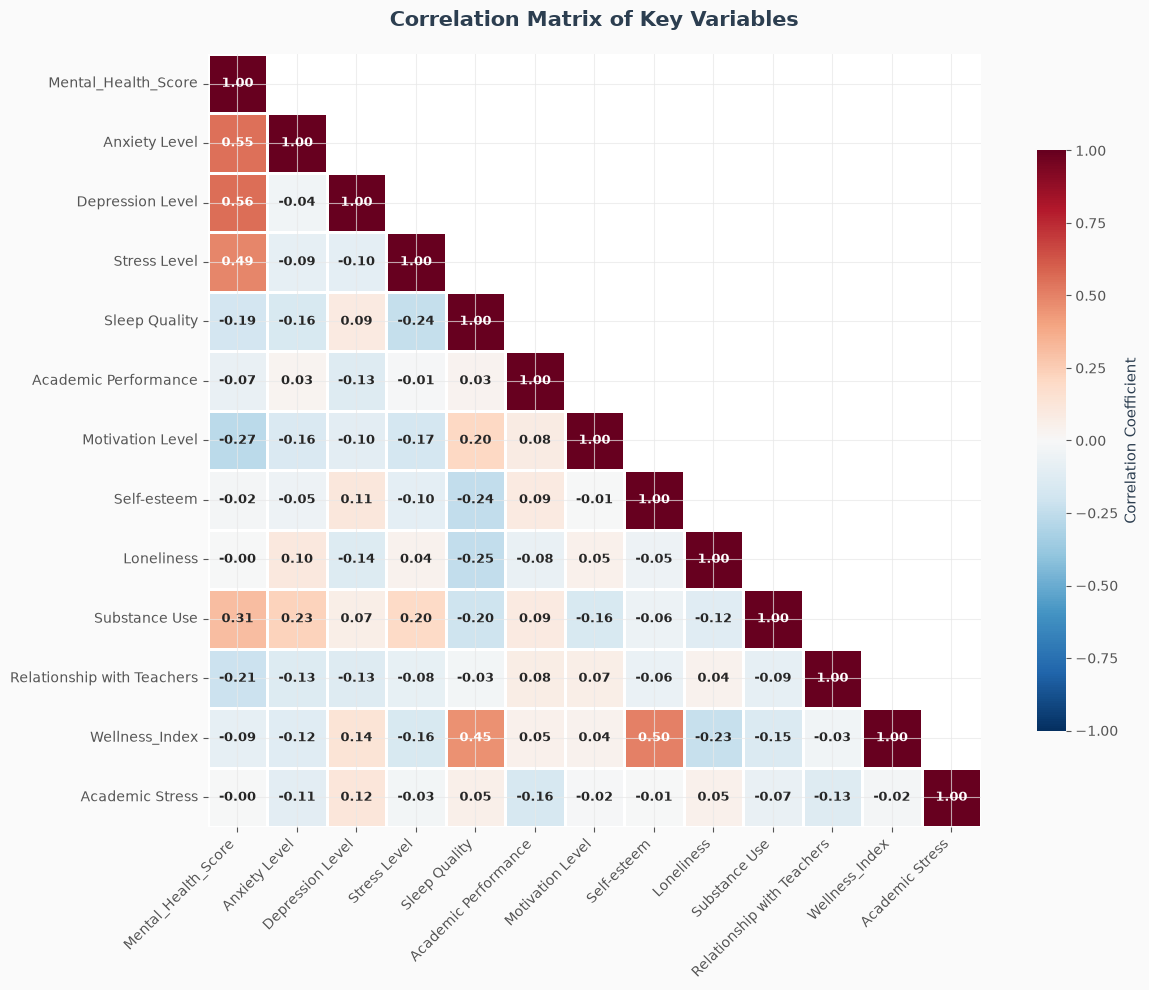

✅ Chart 2 saved: chart2_correlation_heatmap.png


In [38]:
# Select key columns for cleaner heatmap
key_cols = [
    "Mental_Health_Score", "Anxiety Level", "Depression Level",
    "Stress Level", "Sleep Quality", "Academic Performance",
    "Motivation Level", "Self-esteem", "Loneliness",
    "Substance Use", "Relationship with Teachers",
    "Wellness_Index", "Academic Stress"
]

# Calculate correlation matrix
corr_matrix = df_clean[key_cols].corr()

# Create mask for upper triangle (hide redundant half)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=2,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"},
    annot_kws={"size": 9, "weight": "bold"},
    ax=ax
)

ax.set_title("Correlation Matrix of Key Variables",
             fontsize=15, fontweight="bold", color="#2C3E50", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("chart2_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Chart 2 saved: chart2_correlation_heatmap.png")

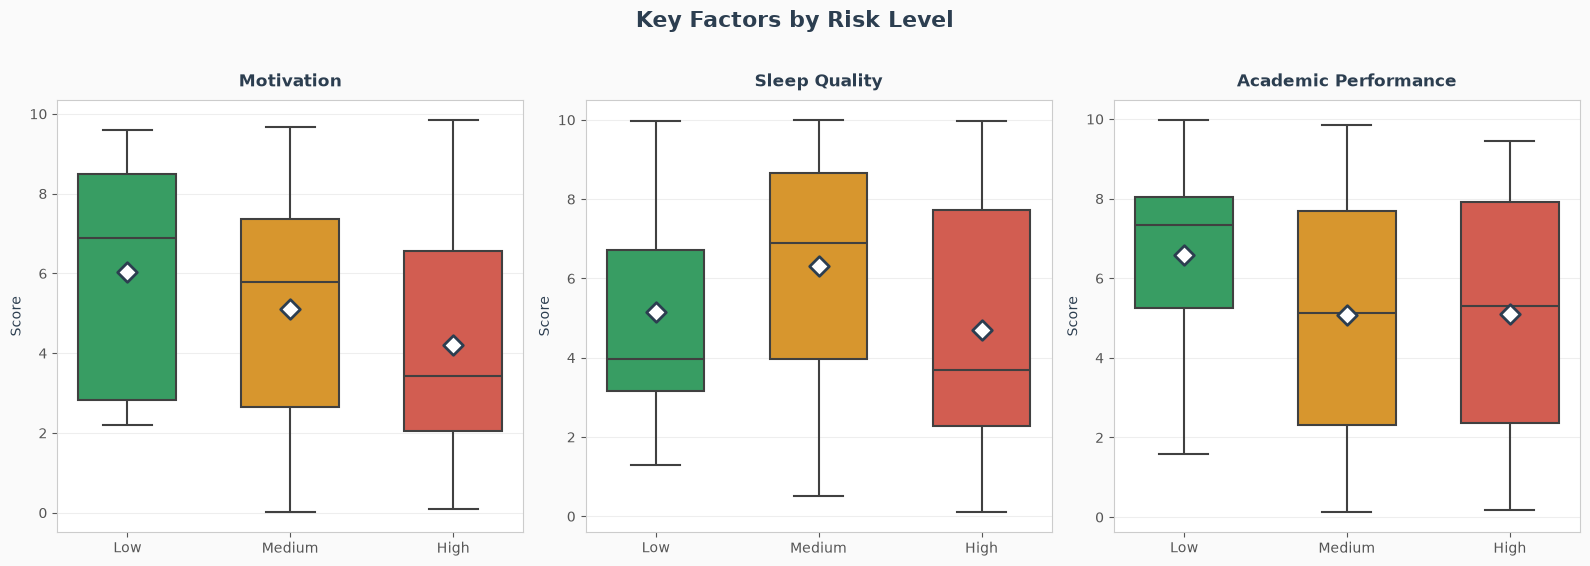

✅ Chart 3 saved: chart3_factors_by_risk.png


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle("Key Factors by Risk Level",
             fontsize=16, fontweight="bold", color="#2C3E50", y=1.02)

factors = [
    ("Motivation Level",     "Motivation"),
    ("Sleep Quality",        "Sleep Quality"),
    ("Academic Performance", "Academic Performance"),
]

for ax, (col, label) in zip(axes, factors):
    sns.boxplot(
        data=df_clean, x="Risk_Level", y=col,
        order=["Low", "Medium", "High"],
        palette=RISK_COLORS,
        width=0.6, linewidth=1.5,
        fliersize=4,
        flierprops={"markerfacecolor": COLORS["gray"]},
        ax=ax
    )

    # Add mean markers
    means = df_clean.groupby("Risk_Level", observed=True)[col].mean()
    for i, level in enumerate(["Low", "Medium", "High"]):
        ax.scatter(i, means[level], color="white", s=100,
                   edgecolor=COLORS["primary"], linewidth=2,
                   zorder=5, marker="D")

    ax.set_title(label, fontsize=12, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Score", fontsize=10)

plt.tight_layout()
plt.savefig("chart3_factors_by_risk.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Chart 3 saved: chart3_factors_by_risk.png")

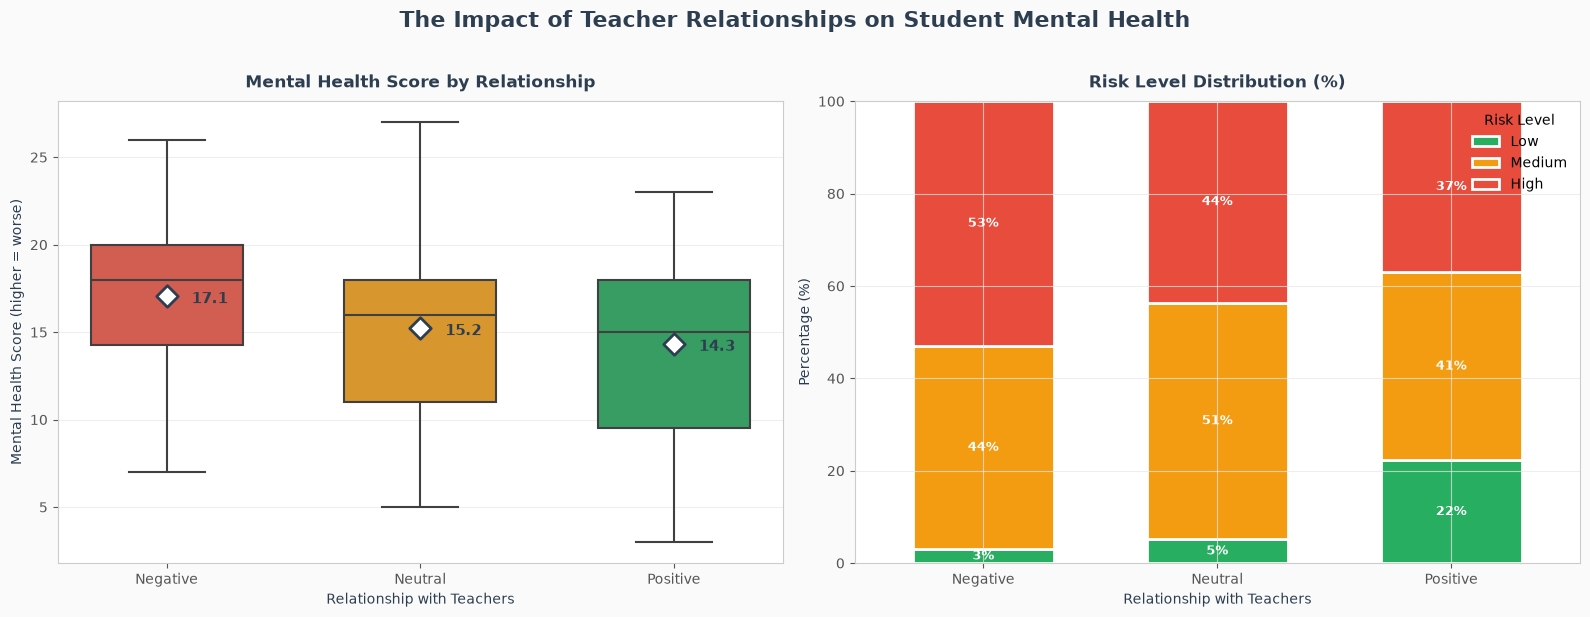

✅ Chart 4 saved: chart4_teacher_impact.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("The Impact of Teacher Relationships on Student Mental Health",
             fontsize=16, fontweight="bold", color="#2C3E50", y=1.02)

teacher_colors = ["#E74C3C", "#F39C12", "#27AE60"]

# --- LEFT: Boxplot ---
sns.boxplot(
    data=df_clean,
    x="Relationship with Teachers",
    y="Mental_Health_Score",
    palette=teacher_colors,
    width=0.6, linewidth=1.5,
    fliersize=4,
    flierprops={"markerfacecolor": COLORS["gray"]},
    ax=axes[0]
)

# Add mean markers + value labels
means = df_clean.groupby("Relationship with Teachers", observed=True)["Mental_Health_Score"].mean()
for i, (key, val) in enumerate(means.items()):
    axes[0].scatter(i, val, color="white", s=120,
                    edgecolor=COLORS["primary"], linewidth=2,
                    zorder=5, marker="D")
    axes[0].annotate(f"{val:.1f}", (i, val),
                     textcoords="offset points", xytext=(18, -5),
                     fontsize=11, fontweight="bold", color=COLORS["primary"])

axes[0].set_xticklabels(["Negative", "Neutral", "Positive"])
axes[0].set_title("Mental Health Score by Relationship",
                  fontsize=12, pad=10)
axes[0].set_xlabel("Relationship with Teachers", fontsize=10)
axes[0].set_ylabel("Mental Health Score (higher = worse)", fontsize=10)

# --- RIGHT: Stacked Bar Chart ---
risk_pct = pd.crosstab(
    df_clean["Relationship with Teachers"],
    df_clean["Risk_Level"],
    normalize="index"
) * 100
risk_pct = risk_pct[["Low", "Medium", "High"]]

risk_pct.plot(
    kind="bar", stacked=True, ax=axes[1],
    color=[RISK_COLORS["Low"], RISK_COLORS["Medium"], RISK_COLORS["High"]],
    edgecolor="white", linewidth=2, width=0.6
)

axes[1].set_xticklabels(["Negative", "Neutral", "Positive"], rotation=0)
axes[1].set_title("Risk Level Distribution (%)", fontsize=12, pad=10)
axes[1].set_xlabel("Relationship with Teachers", fontsize=10)
axes[1].set_ylabel("Percentage (%)", fontsize=10)
axes[1].legend(title="Risk Level", loc="upper right", fontsize=10)
axes[1].set_ylim(0, 100)

# Add percentage labels inside bars
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f%%", label_type="center",
                      fontsize=9, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig("chart4_teacher_impact.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Chart 4 saved: chart4_teacher_impact.png")

In [41]:
import os
os.makedirs("charts", exist_ok=True)
print("✅ Folder 'charts' created!")

✅ Folder 'charts' created!


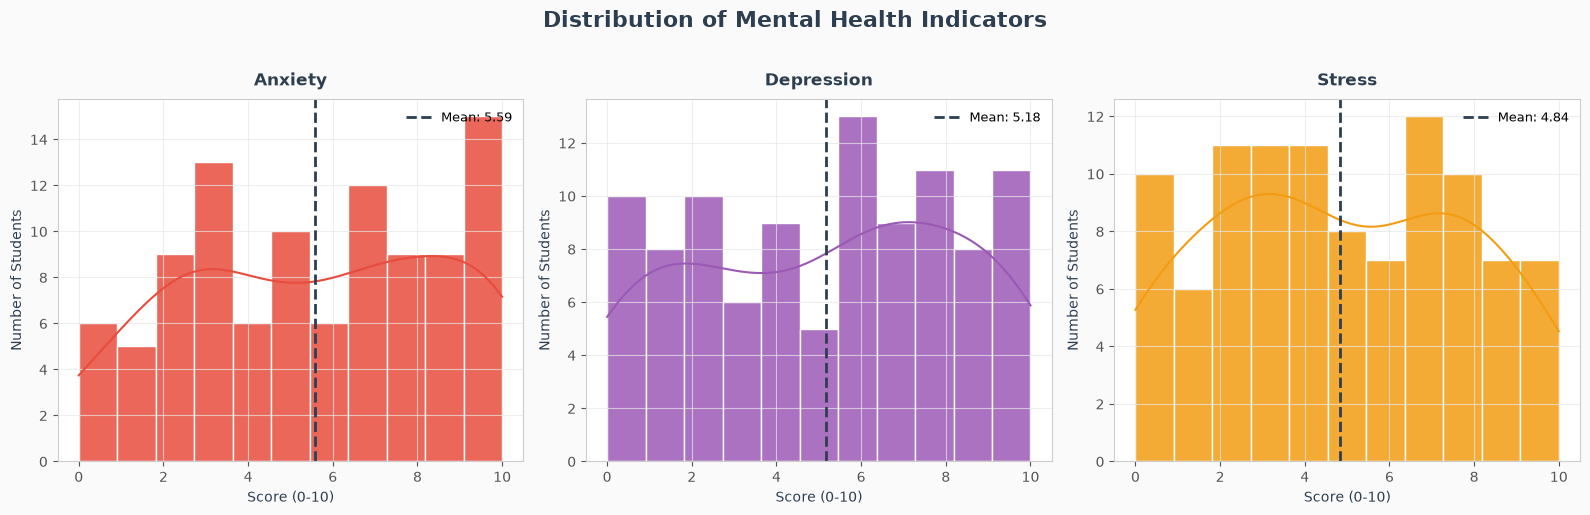

✅ Saved: charts/01_distributions.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution of Mental Health Indicators",
             fontsize=16, fontweight="bold", color="#2C3E50", y=1.02)

indicators = [
    ("Anxiety Level",    COLORS["accent"],  "Anxiety"),
    ("Depression Level", COLORS["purple"],  "Depression"),
    ("Stress Level",     COLORS["warning"], "Stress"),
]

for ax, (col, color, label) in zip(axes, indicators):
    sns.histplot(df_clean[col], bins=11, kde=True, ax=ax,
                 color=color, edgecolor="white", alpha=0.85)
    mean_val = df_clean[col].mean()
    ax.axvline(mean_val, color=COLORS["primary"], linestyle="--",
               linewidth=2, label=f"Mean: {mean_val:.2f}")
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_xlabel("Score (0-10)", fontsize=10)
    ax.set_ylabel("Number of Students", fontsize=10)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim(-0.5, 10.5)

plt.tight_layout()
plt.savefig("charts/01_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: charts/01_distributions.png")

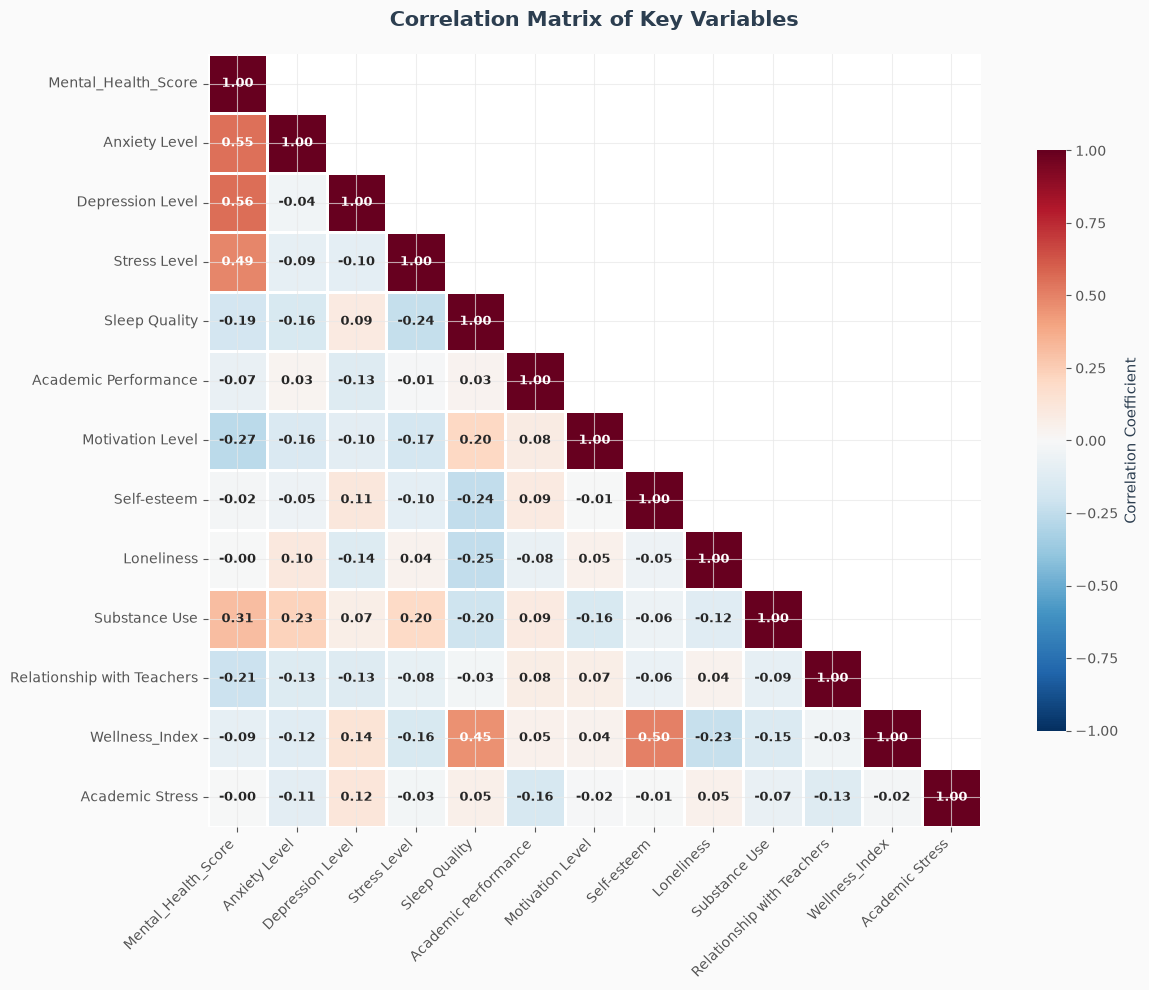

✅ Saved: charts/02_correlation_heatmap.png


In [43]:
key_cols = [
    "Mental_Health_Score", "Anxiety Level", "Depression Level",
    "Stress Level", "Sleep Quality", "Academic Performance",
    "Motivation Level", "Self-esteem", "Loneliness",
    "Substance Use", "Relationship with Teachers",
    "Wellness_Index", "Academic Stress"
]

corr_matrix = df_clean[key_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=2, linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"},
    annot_kws={"size": 9, "weight": "bold"}, ax=ax
)

ax.set_title("Correlation Matrix of Key Variables",
             fontsize=15, fontweight="bold", color="#2C3E50", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("charts/02_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: charts/02_correlation_heatmap.png")

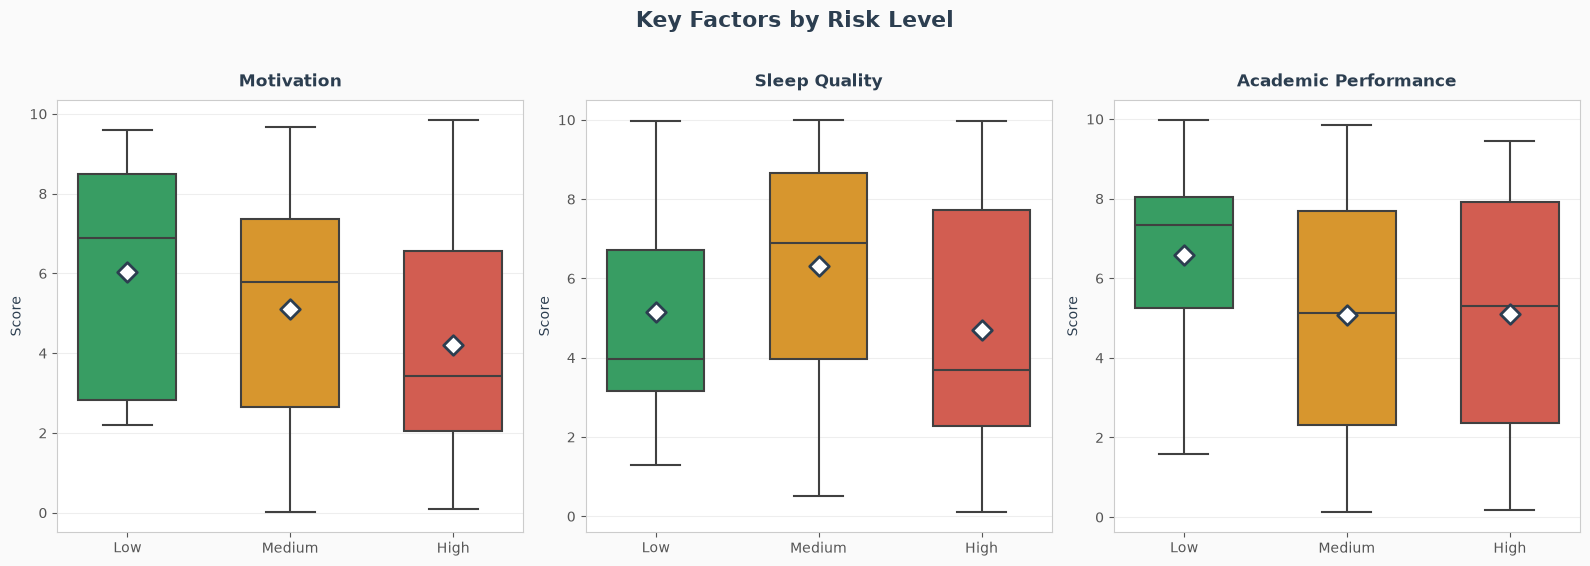

✅ Saved: charts/03_factors_by_risk.png


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle("Key Factors by Risk Level",
             fontsize=16, fontweight="bold", color="#2C3E50", y=1.02)

factors = [
    ("Motivation Level",     "Motivation"),
    ("Sleep Quality",        "Sleep Quality"),
    ("Academic Performance", "Academic Performance"),
]

for ax, (col, label) in zip(axes, factors):
    sns.boxplot(
        data=df_clean, x="Risk_Level", y=col,
        order=["Low", "Medium", "High"],
        palette=RISK_COLORS, width=0.6, linewidth=1.5,
        fliersize=4, flierprops={"markerfacecolor": COLORS["gray"]},
        ax=ax
    )
    means = df_clean.groupby("Risk_Level", observed=True)[col].mean()
    for i, level in enumerate(["Low", "Medium", "High"]):
        ax.scatter(i, means[level], color="white", s=100,
                   edgecolor=COLORS["primary"], linewidth=2,
                   zorder=5, marker="D")
    ax.set_title(label, fontsize=12, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Score", fontsize=10)

plt.tight_layout()
plt.savefig("charts/03_factors_by_risk.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: charts/03_factors_by_risk.png")

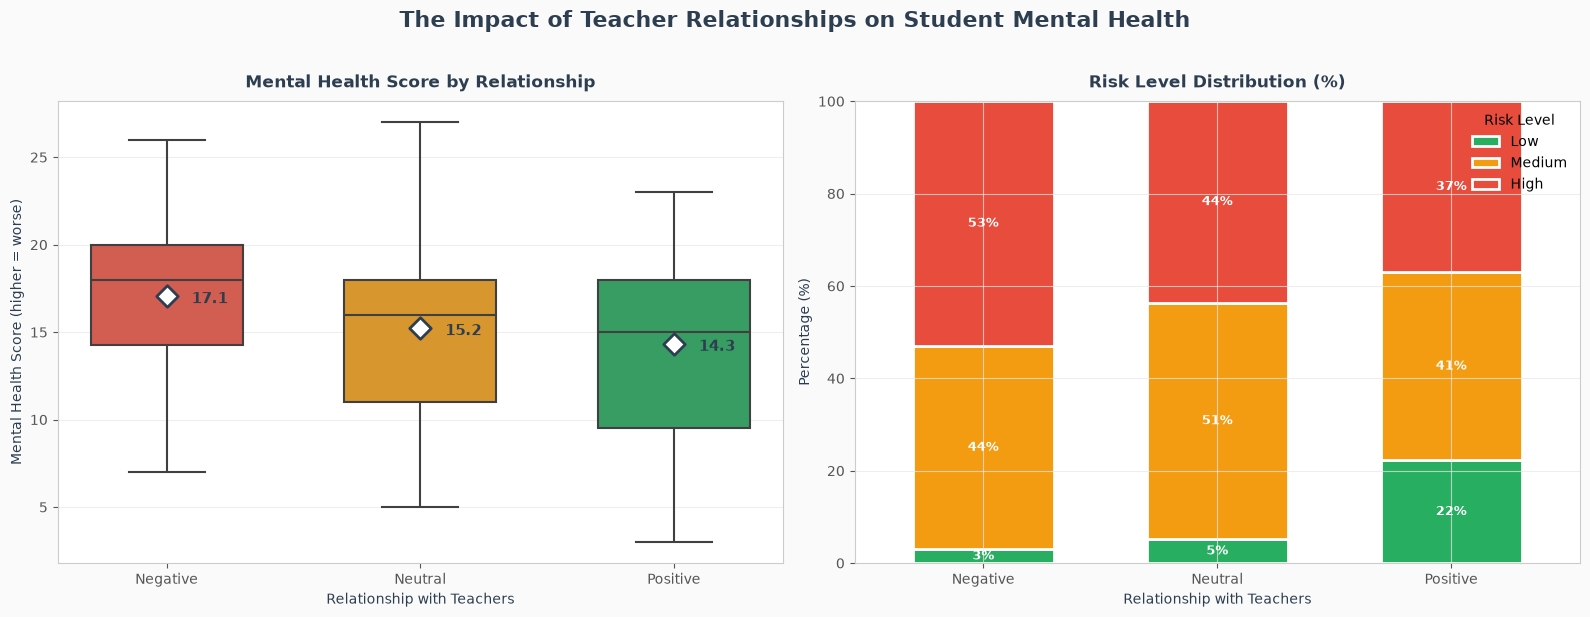

✅ Saved: charts/04_teacher_impact.png


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("The Impact of Teacher Relationships on Student Mental Health",
             fontsize=16, fontweight="bold", color="#2C3E50", y=1.02)

teacher_colors = ["#E74C3C", "#F39C12", "#27AE60"]

# Left: Boxplot
sns.boxplot(
    data=df_clean, x="Relationship with Teachers",
    y="Mental_Health_Score", palette=teacher_colors,
    width=0.6, linewidth=1.5, fliersize=4,
    flierprops={"markerfacecolor": COLORS["gray"]},
    ax=axes[0]
)

means = df_clean.groupby("Relationship with Teachers", observed=True)["Mental_Health_Score"].mean()
for i, (key, val) in enumerate(means.items()):
    axes[0].scatter(i, val, color="white", s=120,
                    edgecolor=COLORS["primary"], linewidth=2,
                    zorder=5, marker="D")
    axes[0].annotate(f"{val:.1f}", (i, val),
                     textcoords="offset points", xytext=(18, -5),
                     fontsize=11, fontweight="bold", color=COLORS["primary"])

axes[0].set_xticklabels(["Negative", "Neutral", "Positive"])
axes[0].set_title("Mental Health Score by Relationship",
                  fontsize=12, pad=10)
axes[0].set_xlabel("Relationship with Teachers", fontsize=10)
axes[0].set_ylabel("Mental Health Score (higher = worse)", fontsize=10)

# Right: Stacked Bar
risk_pct = pd.crosstab(
    df_clean["Relationship with Teachers"],
    df_clean["Risk_Level"],
    normalize="index"
) * 100
risk_pct = risk_pct[["Low", "Medium", "High"]]

risk_pct.plot(
    kind="bar", stacked=True, ax=axes[1],
    color=[RISK_COLORS["Low"], RISK_COLORS["Medium"], RISK_COLORS["High"]],
    edgecolor="white", linewidth=2, width=0.6
)

axes[1].set_xticklabels(["Negative", "Neutral", "Positive"], rotation=0)
axes[1].set_title("Risk Level Distribution (%)", fontsize=12, pad=10)
axes[1].set_xlabel("Relationship with Teachers", fontsize=10)
axes[1].set_ylabel("Percentage (%)", fontsize=10)
axes[1].legend(title="Risk Level", loc="upper right", fontsize=10)
axes[1].set_ylim(0, 100)

for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f%%", label_type="center",
                      fontsize=9, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig("charts/04_teacher_impact.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: charts/04_teacher_impact.png")

In [46]:
import os

# Create processed folder
os.makedirs("processed_data", exist_ok=True)

# Save cleaned data
df_clean.to_csv("processed_data/clean_data.csv", index=False)
print("✅ Saved: processed_data/clean_data.csv")
print("Shape:", df_clean.shape)

✅ Saved: processed_data/clean_data.csv
Shape: (100, 29)


In [47]:
print("📁 charts/ folder:")
for f in os.listdir("charts"):
    size = os.path.getsize(f"charts/{f}") / 1024
    print(f"  - {f} ({size:.0f} KB)")

print("\n📁 processed_data/ folder:")
for f in os.listdir("processed_data"):
    size = os.path.getsize(f"processed_data/{f}") / 1024
    print(f"  - {f} ({size:.0f} KB)")

📁 charts/ folder:
  - 01_distributions.png (183 KB)
  - 02_correlation_heatmap.png (464 KB)
  - 03_factors_by_risk.png (112 KB)
  - 04_teacher_impact.png (196 KB)

📁 processed_data/ folder:
  - clean_data.csv (10 KB)


In [53]:
import os

# Change to project folder
project_path = r"C:\Users\lamar\OneDrive\Desktop\Data\Mental health data"
os.chdir(project_path)

print("✅ New path:", os.getcwd())
print("\n📁 Contents here:")
for item in os.listdir("."):
    print("  -", item)

✅ New path: C:\Users\lamar\OneDrive\Desktop\Data\Mental health data

📁 Contents here:
  - chart1_distributions.png
  - chart2_correlation_heatmap.png
  - chart3_factors_by_risk.png
  - chart4_teacher_impact.png
  - mental_health_evaluation_data.csv
  - Untitled1.ipynb


In [54]:
import os

# Check folders
paths = [
    "data/raw/mental_health_evaluation_data.csv",
    "charts",
    "processed_data",
]

print("📍 Current:", os.getcwd())
print()
for p in paths:
    exists = "✅" if os.path.exists(p) else "❌"
    print(f"{exists} {p}")

📍 Current: C:\Users\lamar\OneDrive\Desktop\Data\Mental health data

❌ data/raw/mental_health_evaluation_data.csv
❌ charts
❌ processed_data


In [55]:
import os

# Make sure we're in the project folder
project = r"C:\Users\lamar\OneDrive\Desktop\Data\Mental health data"
os.chdir(project)
print("📍 Project:", os.getcwd())

# Create folders
folders = [
    "data/raw",
    "data/processed",
    "src",
    "notebooks",
    "outputs/charts",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

📍 Project: C:\Users\lamar\OneDrive\Desktop\Data\Mental health data
✅ Created: data/raw
✅ Created: data/processed
✅ Created: src
✅ Created: notebooks
✅ Created: outputs/charts


In [56]:
import os

print("📁 Final project structure:\n")
for root, dirs, files in os.walk("."):
    if ".ipynb_checkpoints" in root or "venv" in root:
        continue
    level = root.count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root) or '.'}/")
    for file in files:
        if not file.startswith("."):
            print(f"{indent}  ├── {file}")

📁 Final project structure:

./
  ├── chart1_distributions.png
  ├── chart2_correlation_heatmap.png
  ├── chart3_factors_by_risk.png
  ├── chart4_teacher_impact.png
  ├── mental_health_evaluation_data.csv
  ├── Untitled1.ipynb
  data/
    processed/
    raw/
  notebooks/
  outputs/
    charts/
  src/


In [58]:
import os

# Make sure we're in the right folder
project = r"C:\Users\lamar\OneDrive\Desktop\Data\Mental health data"
os.chdir(project)
print("📍 Current:", os.getcwd())
print()
print("📁 Contents here:")
for item in os.listdir("."):
    print("  -", item)

📍 Current: C:\Users\lamar\OneDrive\Desktop\Data\Mental health data

📁 Contents here:
  - chart1_distributions.png
  - chart2_correlation_heatmap.png
  - chart3_factors_by_risk.png
  - chart4_teacher_impact.png
  - data
  - mental_health_evaluation_data.csv
  - notebooks
  - outputs
  - src
  - Untitled1.ipynb


In [59]:
import shutil
import os

print("Starting move...\n")

# 1. Move raw CSV
if os.path.exists("mental_health_evaluation_data.csv"):
    shutil.move("mental_health_evaluation_data.csv",
                "data/raw/mental_health_evaluation_data.csv")
    print("✅ Moved: CSV → data/raw/")
else:
    print("⚠️ CSV not found in root (maybe already moved)")

# 2. Move PNGs
png_files = [
    "chart1_distributions.png",
    "chart2_correlation_heatmap.png",
    "chart3_factors_by_risk.png",
    "chart4_teacher_impact.png",
]
for f in png_files:
    if os.path.exists(f):
        shutil.move(f, f"outputs/charts/{f}")
        print(f"✅ Moved: {f}")
    else:
        print(f"⚠️ {f} not found")

# 3. Move notebook
if os.path.exists("Untitled1.ipynb"):
    shutil.move("Untitled1.ipynb", "notebooks/analysis.ipynb")
    print("✅ Moved: notebook → notebooks/analysis.ipynb")

print("\n🎉 Move done!")

Starting move...

✅ Moved: CSV → data/raw/
✅ Moved: chart1_distributions.png
✅ Moved: chart2_correlation_heatmap.png
✅ Moved: chart3_factors_by_risk.png
✅ Moved: chart4_teacher_impact.png
✅ Moved: notebook → notebooks/analysis.ipynb

🎉 Move done!


In [60]:
import os

print("📁 data/raw/:")
for f in os.listdir("data/raw"):
    print("  -", f)

print("\n📁 outputs/charts/:")
for f in os.listdir("outputs/charts"):
    print("  -", f)

print("\n📁 notebooks/:")
for f in os.listdir("notebooks"):
    print("  -", f)

print("\n📁 Root folder:")
for item in os.listdir("."):
    if not item.startswith(".") and os.path.isfile(item):
        print("  -", item)

📁 data/raw/:
  - mental_health_evaluation_data.csv

📁 outputs/charts/:
  - chart1_distributions.png
  - chart2_correlation_heatmap.png
  - chart3_factors_by_risk.png
  - chart4_teacher_impact.png

📁 notebooks/:
  - analysis.ipynb

📁 Root folder:


In [61]:
import pandas as pd
import os

# Make sure we're in the right folder
os.chdir(r"C:\Users\lamar\OneDrive\Desktop\Data\Mental health data")

# 1. Load raw data
df = pd.read_csv("data/raw/mental_health_evaluation_data.csv")
print(f"✅ Loaded: {df.shape}")

# 2. Drop empty column
df_clean = df.copy()
df_clean = df_clean.drop(columns=["Social Interaction Frequency"])

# 3. Encode categorical columns
mappings = {
    "Nutrition Quality": {"Poor": 0, "Moderate": 1, "Good": 2},
    "Substance Use": {"No": 0, "Yes": 1},
    "Family Support": {"Low": 0, "Medium": 1, "High": 2},
    "Peer Support": {"Low": 0, "Medium": 1, "High": 2},
    "Sleep Pattern Consistency": {"Irregular": 0, "Regular": 1},
    "Peer Pressure": {"No": 0, "Yes": 1},
    "Eating Habits": {"Unhealthy": 0, "Moderate": 1, "Healthy": 2},
    "Social Media Addiction": {"No": 0, "Yes": 1},
    "Relationship with Teachers": {"Negative": 0, "Neutral": 1, "Positive": 2},
}
for col, mapping in mappings.items():
    df_clean[col] = df_clean[col].map(mapping)

# 4. Add engineered features
df_clean["Mental_Health_Score"] = (
    df_clean["Anxiety Level"] + df_clean["Depression Level"] + df_clean["Stress Level"]
)
df_clean["Wellness_Index"] = (
    df_clean["Sleep Quality"] + df_clean["Self-esteem"] + df_clean["Emotional Stability"]
) / 3
df_clean["Social_Support_Score"] = df_clean["Family Support"] + df_clean["Peer Support"]
df_clean["Risk_Level"] = pd.cut(
    df_clean["Mental_Health_Score"],
    bins=[-1, 8, 16, 30],
    labels=["Low", "Medium", "High"]
)

# 5. Save
df_clean.to_csv("data/processed/clean_data.csv", index=False)
print(f"💾 Saved: data/processed/clean_data.csv")
print(f"   Shape: {df_clean.shape}")

✅ Loaded: (100, 26)
💾 Saved: data/processed/clean_data.csv
   Shape: (100, 29)


In [62]:
import os

print("✅ Checking project files:\n")
files = [
    "data/raw/mental_health_evaluation_data.csv",
    "data/processed/clean_data.csv",
    "outputs/charts/chart1_distributions.png",
    "outputs/charts/chart2_correlation_heatmap.png",
    "outputs/charts/chart3_factors_by_risk.png",
    "outputs/charts/chart4_teacher_impact.png",
    "notebooks/analysis.ipynb",
]

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"✅ {f} ({size:.0f} KB)")
    else:
        print(f"❌ {f}")

✅ Checking project files:

✅ data/raw/mental_health_evaluation_data.csv (12 KB)
✅ data/processed/clean_data.csv (10 KB)
✅ outputs/charts/chart1_distributions.png (184 KB)
✅ outputs/charts/chart2_correlation_heatmap.png (464 KB)
✅ outputs/charts/chart3_factors_by_risk.png (112 KB)
✅ outputs/charts/chart4_teacher_impact.png (196 KB)
✅ notebooks/analysis.ipynb (723 KB)
